## Solution Task 1a

1. **Deviation from the ideal solution**

A deviation from the ideal solution refers to the difference between the result obtained from a real quantum device and the result expected from an ideal, noise-free execution of the same quantum circuit. Such deviations occur due to decoherence, imperfect gate operations, state preparation errors, and measurement noise present in current quantum hardware.

2. **Role of a simulator or emulator**

A simulator or emulator is required to define the reference distribution \(S\) because it provides the exact or noise-free outcome of a quantum circuit. This is feasible for small systems or low-depth circuits, where classical simulation is tractable, but becomes infeasible for large-scale quantum circuits due to exponential resource requirements.

3. **Error mitigation vs.\ quantum error correction**

Error mitigation consists of post-processing and calibration techniques that reduce the impact of errors on measured results without actively correcting errors during computation. In contrast, quantum error correction encodes logical qubits into many physical qubits and uses syndrome measurements to detect and correct errors in real time, requiring significantly more resources and fault-tolerant hardware.


## Solution Task 1b

We are given the reference (ideal) distribution `S`, the raw device distribution `V`, and the mitigated distribution `X`:

$$
S=\begin{pmatrix}0.50\\0.25\\0.15\\0.10\end{pmatrix},\quad
V=\begin{pmatrix}0.45\\0.30\\0.15\\0.10\end{pmatrix},\quad
X=\begin{pmatrix}0.48\\0.27\\0.15\\0.10\end{pmatrix}.
$$

The RMS distance to the reference distribution is defined as

$$
\Delta Y=\sqrt{\sum_{k=1}^{4}(y_k-s_k)^2},\quad Y\in\{V,X\}.
$$

---

### 1) Valid probability distributions

A vector is a valid probability distribution if:

1. All entries are in the interval $[0,1]$
2. The entries sum to 1

All entries of `S`, `V`, and `X` lie in $[0,1]$.

The sums are:

$$
\sum_k s_k = 0.50+0.25+0.15+0.10 = 1.00,
$$

$$
\sum_k v_k = 0.45+0.30+0.15+0.10 = 1.00,
$$

$$
\sum_k x_k = 0.48+0.27+0.15+0.10 = 1.00.
$$

Therefore, **all three vectors represent valid probability distributions**.

---

### 2) RMS distances

**Raw device output**

$$
V-S=
\begin{pmatrix}
-0.05\\
\phantom{-}0.05\\
0\\
0
\end{pmatrix}.
$$

$$
\sum_{k=1}^{4}(v_k-s_k)^2 = (-0.05)^2 + (0.05)^2 = 0.005,
$$

$$
\Delta V = \sqrt{0.005} \approx 0.0707.
$$

**Mitigated output**

$$
X-S=
\begin{pmatrix}
-0.02\\
\phantom{-}0.02\\
0\\
0
\end{pmatrix}.
$$

$$
\sum_{k=1}^{4}(x_k-s_k)^2 = (-0.02)^2 + (0.02)^2 = 0.0008,
$$

$$
\Delta X = \sqrt{0.0008} \approx 0.0283.
$$

---

### 3) Evaluation of error mitigation

Since

$$
\Delta X < \Delta V,
$$

the mitigated result is closer to the ideal reference distribution than the raw device output.

**Conclusion:**  
The error mitigation is successful according to the RMS distance criterion.


## Solution Task 1c

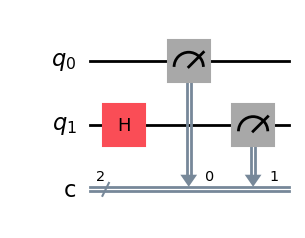

In [30]:
# Task 1c (Qiskit): 2-qubit circuit, noisy measurements -> vectors, RMS distance
# Notes:
# - Uses Qiskit Aer with a simple depolarizing + readout noise model.
# - Produces normalized probability vectors over bitstrings [00, 01, 10, 11] (little-endian convention).
# - "S" is taken from the ideal (noise-free) simulation of the same circuit.

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit_aer.noise.errors.standard_errors import thermal_relaxation_error
from qiskit.result import Counts
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# 1) Initialize a 2-qubit circuit with one Hadamard on the second qubit (qubit 1)
# ----------------------------
qc = QuantumCircuit(2, 2)
qc.h(1)                 # Hadamard on the second qubit (index 1)
qc.measure([0, 1], [0, 1])

# ----------------------------
# Helpers: counts -> normalized vector (ordered basis)
# ----------------------------
BASIS = ["00", "01", "10", "11"]  # basis order for vectors

def counts_to_prob_vector(counts: Counts, shots: int, basis=BASIS):
    """Convert Qiskit counts dict into a normalized probability vector in given basis order."""
    vec = [0.0] * len(basis)
    for i, b in enumerate(basis):
        vec[i] = counts.get(b, 0) / shots
    # Numerical safety: renormalize (should already sum to 1.0)
    s = sum(vec)
    if s > 0:
        vec = [v / s for v in vec]
    return vec

# ----------------------------
# 2) Produce noisy measurements and construct solution vectors (normalized)
# ----------------------------
shots = 20_000

# Ideal (noise-free) reference distribution S
ideal_sim = AerSimulator()  # no noise
ideal_result = ideal_sim.run(qc, shots=shots).result()
ideal_counts = ideal_result.get_counts()
S = counts_to_prob_vector(ideal_counts, shots)

# Build a noise model (example: depolarizing + readout error)
noise_model = NoiseModel()

# Depolarizing errors on gates (typical toy values; adjust as needed)
p1 = 0.01  # 1-qubit depolarizing probability
p2 = 0.03  # 2-qubit depolarizing probability (not used here, but included for completeness)
noise_model.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["h"])

# Readout error (bit-flip during measurement)
# P(0->1)=r01, P(1->0)=r10
r01, r10 = 0.02, 0.03
ro_err = ReadoutError([[1 - r01, r01],
                       [r10, 1 - r10]])
noise_model.add_all_qubit_readout_error(ro_err)

# Noisy device result vector V
noisy_sim = AerSimulator(noise_model=noise_model)
noisy_result = noisy_sim.run(qc, shots=shots).result()
noisy_counts = noisy_result.get_counts()
V = counts_to_prob_vector(noisy_counts, shots)

# Optional placeholder for a "mitigated" vector X
# (You can overwrite later once you implement mitigation routines.)
X = V[:]  # start with raw as a placeholder

# Sanity checks: all vectors are normalized probability distributions
def is_prob_dist(vec, tol=1e-9):
    return (all((v >= -tol and v <= 1 + tol) for v in vec) and abs(sum(vec) - 1.0) <= 1e-6)

assert is_prob_dist(S), "S is not a valid probability distribution"
assert is_prob_dist(V), "V is not a valid probability distribution"
assert is_prob_dist(X), "X is not a valid probability distribution"

#print("Circuit:\n", qc)
qc.draw('mpl')

In [31]:
print("S (ideal):", S, "sum=", sum(S))
print("V (noisy):", V, "sum=", sum(V))

# ----------------------------
# 3) RMS distance function ΔY
# ----------------------------
def rms_distance(Y, S_ref):
    """Compute RMS distance ΔY = sqrt(sum_k (Y_k - S_k)^2)."""
    if len(Y) != len(S_ref):
        raise ValueError("Vectors must have the same length.")
    return math.sqrt(sum((y - s) ** 2 for y, s in zip(Y, S_ref)))

delta_V = rms_distance(V, S)
delta_X = rms_distance(X, S)

print("ΔV =", delta_V)
print("ΔX =", delta_X)

S (ideal): [0.5006, 0.0, 0.4994, 0.0] sum= 1.0
V (noisy): [0.492, 0.00985, 0.48805, 0.0101] sum= 1.0
ΔV = 0.02004532364418199
ΔX = 0.02004532364418199


## Solution Task 2a

Basis order: ['00', '01', '10', '11']
Column sums: [1. 1. 1. 1.]


Text(0.5, 1.0, 'Calibration Matrix M')

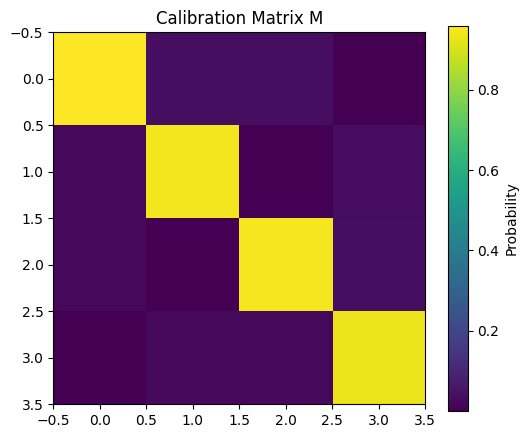

In [32]:
# Task 2a (Qiskit): Construct the 2-qubit error mitigation matrix M via calibration circuits
# Same setup style as before: AerSimulator + NoiseModel, producing probability vectors over ["00","01","10","11"].

# ----------------------------
# Noise model (reuse or adapt to match your previous setup)
# ----------------------------
noise_model = NoiseModel()

# Example gate noise (not essential for pure readout calibration, but included to keep setup consistent)
p1 = 0.01
noise_model.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["x", "h", "id"])

# Example readout noise
r01, r10 = 0.02, 0.03
ro_err = ReadoutError([[1 - r01, r01],
                       [r10, 1 - r10]])
noise_model.add_all_qubit_readout_error(ro_err)

noisy_sim = AerSimulator(noise_model=noise_model)

# ----------------------------
# Helpers
# ----------------------------

def prep_basis_state_circuit(bitstring, n_qubits=2):
    """
    Prepare a computational basis state |bitstring> on n_qubits and measure.
    bitstring is a string like "00", "01", "10", "11".
    Qiskit uses little-endian qubit indexing; here we interpret bitstring as:
      left char -> qubit 1, right char -> qubit 0 for 2 qubits,
    so that measurement keys match BASIS ordering.
    """
    if len(bitstring) != n_qubits:
        raise ValueError("bitstring length must equal n_qubits")

    qc = QuantumCircuit(n_qubits, n_qubits)

    # Apply X on qubit i when corresponding bit is 1.
    # For 2 qubits, BASIS strings are "q1q0" in the counts key.
    for q in range(n_qubits):
        bit = bitstring[n_qubits - 1 - q]  # map q=0 -> last char, q=1 -> first char
        if bit == "1":
            qc.x(q)

    qc.measure(range(n_qubits), range(n_qubits))
    return qc

# ----------------------------
# Construct M: columns are V^(j) for prepared basis state j
# ----------------------------
shots = 20_000
n_qubits = 2
dim = 2**n_qubits

M = np.zeros((dim, dim), dtype=float)

for col, state in enumerate(BASIS):
    calib_circuit = prep_basis_state_circuit(state, n_qubits=n_qubits)
    result = noisy_sim.run(calib_circuit, shots=shots).result()
    counts = result.get_counts()
    Vj = counts_to_prob_vector(counts, shots, basis=BASIS)  # measurement outcome distribution
    M[:, col] = Vj  # assign as column

# Sanity checks
# Each column should sum to 1 (it is a probability distribution)
col_sums = M.sum(axis=0)
if not np.allclose(col_sums, np.ones(dim), atol=1e-3):
    raise RuntimeError(f"Calibration columns not normalized. Column sums: {col_sums}")

print("Basis order:", BASIS)
print("Column sums:", col_sums)

plt.figure(figsize=(6,5))
plt.imshow(M, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Probability')
plt.title('Calibration Matrix M')


## Solution Task 2b

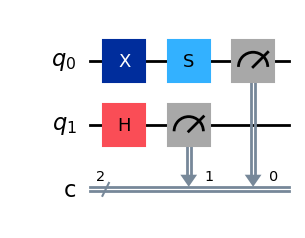

In [23]:
# Task 2b (Qiskit): Run the given 2-qubit circuit with few shots, mitigate using M from Task 2a, compare
# Assumes you already executed Task 2a code and therefore have:
#   - M (4x4 numpy array)
#   - BASIS = ["00","01","10","11"]
#   - counts_to_prob_vector(counts, shots, basis=...)
#   - noisy_sim (AerSimulator with the same noise model used to build M)

# ----------------------------
# 1) Define and execute the circuit with few shots (more sampling noise)
# Circuit:
# |0> -- X -- S -- (measure)
# |0> -- H ------- (measure)
# ----------------------------
qc_target = QuantumCircuit(2, 2)
qc_target.x(0)
qc_target.s(0)
qc_target.h(1)
qc_target.measure([0, 1], [0, 1])

shots_small = 128  # few shots -> noisier estimate

qc_target.draw('mpl')

In [24]:


# Run on the noisy simulator (same noise model used for calibration)
res_noisy = noisy_sim.run(qc_target, shots=shots_small).result()
counts_noisy = res_noisy.get_counts()
V_circ = counts_to_prob_vector(counts_noisy, shots_small, basis=BASIS)

# ----------------------------
# 2) Mitigate using M from Task 2a
# Solve M X = V for X (avoid explicit inverse when possible)
# ----------------------------
V_vec = np.array(V_circ, dtype=float)

try:
    X_mitig = np.linalg.solve(M, V_vec)  # numerically preferable to inv(M) @ V
except np.linalg.LinAlgError:
    # Fallback if M is singular/ill-conditioned: least-squares solution
    X_mitig, *_ = np.linalg.lstsq(M, V_vec, rcond=None)

# Optional: project to a valid probability distribution (simple post-processing)
# (Direct inversion can yield small negative entries due to noise/conditioning.)
X_mitig_proj = np.clip(X_mitig, 0.0, None)
s = X_mitig_proj.sum()
if s > 0:
    X_mitig_proj /= s

# ----------------------------
# 3) Compare raw vs mitigated (and optionally ideal reference)
# ----------------------------
ideal_sim = AerSimulator()  # noise-free reference
res_ideal = ideal_sim.run(qc_target, shots=50_000).result()
counts_ideal = res_ideal.get_counts()
S_ref = counts_to_prob_vector(counts_ideal, 50_000, basis=BASIS)

# Prepare comparison table
df = pd.concat([pd.Series(BASIS), pd.Series(V_vec), pd.Series(X_mitig), pd.Series(X_mitig_proj), pd.Series(S_ref)], axis=1)
df.columns = ['bitstring', 'raw V', 'mitigated X (solve)', 'mitigated X (clipped+renorm)', 'ideal S']

print(f"Shots (noisy run): {shots_small}")
print("Counts (noisy):", counts_noisy)
print("\nBasis order:", BASIS)

# Print a compact comparison
print("\nComparison (probabilities):")
df


Shots (noisy run): 128
Counts (noisy): {'01': 68, '11': 54, '00': 3, '10': 3}

Basis order: ['00', '01', '10', '11']

Comparison (probabilities):


,bitstring,raw V,mitigated X (solve),mitigated X (clipped+renorm),ideal S
0,00,0.023438,0.004294,0.004294,0.00000
1,01,0.531250,0.547488,0.547488,0.50154
2,10,0.023438,0.008270,0.008270,0.00000
3,11,0.421875,0.439947,0.439947,0.49846


In [25]:
print("\nSanity checks:")
print("sum(raw V)               =", float(np.sum(V_vec)))
print("sum(mitigated X)         =", float(np.sum(X_mitig)))
print("sum(mitigated X proj)    =", float(np.sum(X_mitig_proj)))
print("min(mitigated X)         =", float(np.min(X_mitig)))
print("min(mitigated X proj)    =", float(np.min(X_mitig_proj)))

# Optional: quantify closeness to ideal using RMS distance
import math
def rms_distance(Y, S):
    return math.sqrt(float(np.sum((np.array(Y) - np.array(S)) ** 2)))

print("\nRMS distance to ideal reference S:")
print("Δ(raw V)            =", rms_distance(V_vec, S_ref))
print("Δ(mitigated X)      =", rms_distance(X_mitig, S_ref))
print("Δ(mitigated X proj) =", rms_distance(X_mitig_proj, S_ref))


Sanity checks:
sum(raw V)               = 1.0
sum(mitigated X)         = 1.0000000000000002
sum(mitigated X proj)    = 1.0
min(mitigated X)         = 0.004294178635204858
min(mitigated X proj)    = 0.0042941786352048575

RMS distance to ideal reference S:
Δ(raw V)            = 0.08858091858577673
Δ(mitigated X)      = 0.07497909124141115
Δ(mitigated X proj) = 0.07497909124141117


## Solution Task 2c

We assume the (calibrated) error model relates the ideal/mitigated distribution $X$ to the measured distribution $V$ via

$$
M X \approx V,
$$

where $M \in \mathbb{R}^{2^N \times 2^N}$ is the error mitigation (calibration) matrix, $V$ is the observed probability vector from hardware, and $X$ is the unknown, mitigated probability vector we want to estimate.

---

### 1) Meaning of the least squares objective

We define the least squares objective

$$
f(X) = \sum_{i=1}^{2^N}\left(v_i - (MX)_i\right)^2
     = \|V - MX\|_2^2.
$$

**Interpretation:**  
This objective measures the *total squared mismatch* between

- the actually observed noisy distribution $V$, and
- the distribution predicted by the calibration model $MX$ when we assume the true distribution is $X$.

Minimizing $f(X)$ finds the $X$ whose forward-noise prediction $MX$ best fits the observed data in the Euclidean (L2) sense.

---

### 2) Physical constraints for $X$ to be a probability distribution
For $X$ to be a valid probability distribution over computational basis states, it must satisfy:

1. **Non-negativity:**  
   $$
   x_i \ge 0 \quad \text{for all } i.
   $$

2. **Normalization (unit sum):**  
   $$
   \sum_{i=1}^{2^N} x_i = 1.
   $$

(Equivalently, $X$ lies on the probability simplex.)

---

### 3) Complete constrained optimization problem and comparison to inversion

The constrained least squares mitigation problem is:

$$
\begin{aligned}
\text{minimize}_{X \in \mathbb{R}^{2^N}} \quad & \|V - MX\|_2^2 \\
\text{subject to} \quad & x_i \ge 0 \quad \forall i, \\
& \sum_{i=1}^{2^N} x_i = 1.
\end{aligned}
$$

#### Comparison to direct inversion \( $ X = M^{-1}V $ \)

- **Direct inversion** provides a closed-form estimate, but it can be **numerically unstable** when $M$ is ill-conditioned (small calibration errors can be amplified).
- Inversion can also yield **unphysical results**, e.g. negative components or entries larger than 1, and a sum different from 1 (violating probability axioms).
- **Constrained least squares** explicitly enforces the probability constraints, producing a result that is **physically meaningful by construction** and typically more robust to calibration noise and finite-shot fluctuations.

In practice, the constrained least squares approach is therefore often preferred when $M$ is noisy, nearly singular, or when physical validity of $X$ is critical.


## Solution Task 3a

1. **Why the earlier technique only mitigates state preparation and measurement errors**

The earlier calibration-based method prepares computational basis states and measures them directly. Since no circuit gates are applied during calibration, the resulting matrix captures only errors occurring during state preparation and readout, but not errors introduced by gate operations within a quantum circuit.

2. **Motivation for inserting gates and their inverses into calibration circuits**

By inserting circuit gates followed by their exact inverses, the ideal (noise-free) action is the identity, while noise from the gates remains. This allows the calibration procedure to capture **gate-dependent errors**, such as over-rotations, decoherence during gate execution, and control imperfections.

3. **Why the circuit is split into two halves and \( $ M_1 $ \), \( $ M_2 $ \) are averaged**

Splitting the circuit reduces the depth of individual calibration circuits, limiting error accumulation and improving numerical stability. Constructing two calibration matrices for different gate subsets and averaging them provides a more balanced estimate of gate-induced noise across the circuit and reduces bias from any single calibration configuration.


## Solution Task 3b

Computational basis states: ['00', '01', '10', '11']


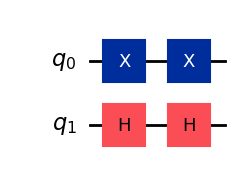

In [33]:
# Task 3b (Qiskit): Construct mitigation matrix M including gate errors via "half-circuit + inverse" calibration
# Circuit:
#   q0: |0> -- X -- S --
#   q1: |0> -- H -- Z --
#
# We build two calibration matrices:
#   M1: calibrate noise for the first half (layer 1) using U1 then U1^{-1}
#   M2: calibrate noise for the second half (layer 2) using U2 then U2^{-1}
# Final:
#   M = 0.5 * (M1 + M2)
#
# This cell relies on previous notebook structures from Task 2a:
#   - BASIS = ["00","01","10","11"]
#   - counts_to_prob_vector(counts, shots, basis=...)
#   - prep_basis_state_circuit(bitstring, n_qubits=2)  (we will reuse its preparation logic)
#   - noisy_sim : AerSimulator with the SAME noise model you will later mitigate with
#
# If you used a different naming earlier, adapt the variable/function names accordingly.

# ----------------------------
# 1) List all computational basis states (for N=2)
# ----------------------------
print("Computational basis states:", BASIS)

# ----------------------------
# Helper: prepare basis state without measurement (so we can append gates and then measure)
# ----------------------------
def prep_basis_state_no_measure(bitstring, n_qubits=2):
    """
    Prepare |bitstring> on n_qubits, WITHOUT measurements.
    bitstring is in the counts-key convention "q1q0" for 2 qubits, matching BASIS order.
    """
    if len(bitstring) != n_qubits:
        raise ValueError("bitstring length must equal n_qubits")

    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        bit = bitstring[n_qubits - 1 - q]  # q=0 -> last char, q=1 -> first char
        if bit == "1":
            qc.x(q)
    return qc

# ----------------------------
# Define half-circuit unitaries U1 and U2 (as gate layers)
# We use two layers:
#   Layer 1 (first half): X on q0, H on q1
#   Layer 2 (second half): S on q0, Z on q1
# Their inverses:
#   X^{-1} = X, H^{-1} = H, Z^{-1} = Z, S^{-1} = Sdg
# ----------------------------
def apply_layer_1(qc: QuantumCircuit):
    qc.x(0)
    qc.h(1)

def apply_layer_1_inv(qc: QuantumCircuit):
    # inverse in reverse order of application: (H on q1) then (X on q0)
    qc.h(1)
    qc.x(0)

def apply_layer_2(qc: QuantumCircuit):
    qc.s(0)
    qc.z(1)

def apply_layer_2_inv(qc: QuantumCircuit):
    # inverse in reverse order: (Z on q1) then (S on q0)^{-1} = Sdg
    qc.z(1)
    qc.sdg(0)

# ----------------------------
# Build a calibration matrix for a given layer: prepare |j>, apply U, apply U^{-1}, measure
# Columns correspond to prepared states j, and entries are measured output probabilities
# ----------------------------
def build_layer_calibration_matrix(apply_layer, apply_layer_inv, shots=20_000):
    dim = len(BASIS)
    M_layer = np.zeros((dim, dim), dtype=float)

    for col, state in enumerate(BASIS):
        qc = prep_basis_state_no_measure(state, n_qubits=2)
        qc.add_register(*[])  # no-op; keeps structure explicit

        # Apply U then U^{-1}
        apply_layer(qc)
        apply_layer_inv(qc)

        # Measure in Z basis (computational basis)
        qc_meas = QuantumCircuit(2, 2)
        qc_meas.compose(qc, inplace=True)
        qc_meas.measure([0, 1], [0, 1])

        # Run on the same noisy simulator used elsewhere
        res = noisy_sim.run(qc_meas, shots=shots).result()
        counts = res.get_counts()
        Vj = counts_to_prob_vector(counts, shots, basis=BASIS)
        M_layer[:, col] = Vj

    # sanity: each column should sum to 1
    col_sums = M_layer.sum(axis=0)
    if not np.allclose(col_sums, np.ones(dim), atol=1e-3):
        raise RuntimeError(f"Calibration columns not normalized. Column sums: {col_sums}")

    return M_layer

# plot the reversed circuits
# layer 1 + inverse
qc1 = prep_basis_state_no_measure("00", n_qubits=2)
apply_layer_1(qc1)
apply_layer_1_inv(qc1)
qc1.draw('mpl')


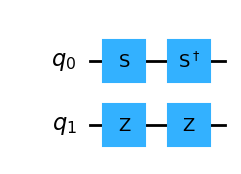

In [34]:
# layer 2 + inverse
qc2 = prep_basis_state_no_measure("00", n_qubits=2)
apply_layer_2(qc2)
apply_layer_2_inv(qc2)
qc2.draw('mpl')


M1 (layer 1 calibration):



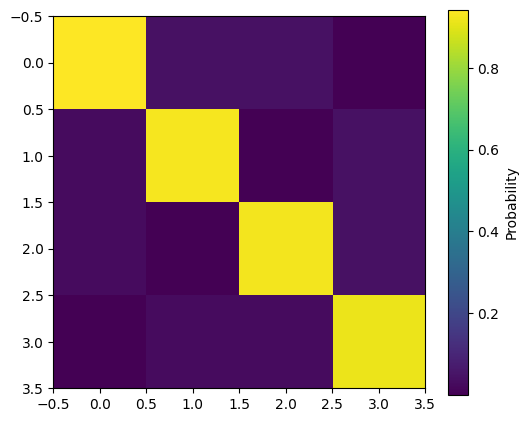


M2 (layer 2 calibration):



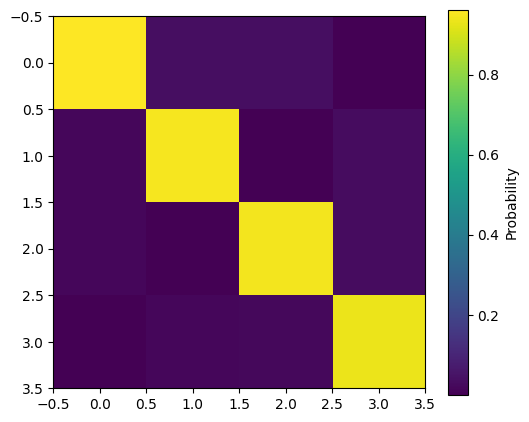


Final M = 0.5*(M1+M2):



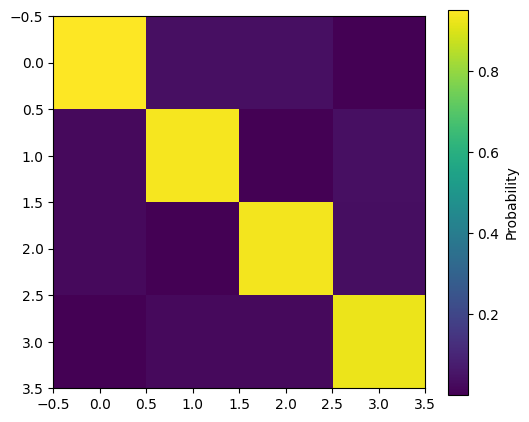


Column sums of final M: [1. 1. 1. 1.]


In [37]:
# ----------------------------
# 2) Construct M1 from layer 1, and M2 from layer 2
# ----------------------------
shots_cal = 20_000  # calibration shots (increase if you want smoother M)
M1 = build_layer_calibration_matrix(apply_layer_1, apply_layer_1_inv, shots=shots_cal)
M2 = build_layer_calibration_matrix(apply_layer_2, apply_layer_2_inv, shots=shots_cal)

# ----------------------------
# 3) Combine to obtain final M
# ----------------------------
M_gate = 0.5 * (M1 + M2)

print("\nM1 (layer 1 calibration):\n")
plt.figure(figsize=(6,5))
plt.imshow(M1, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Probability')
plt.show()
print("\nM2 (layer 2 calibration):\n")
plt.figure(figsize=(6,5))
plt.imshow(M2, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Probability')
plt.show()
print("\nFinal M = 0.5*(M1+M2):\n")
plt.figure(figsize=(6,5))
plt.imshow(M_gate, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Probability')
plt.show()
# Optional: store under the same name "M" used later for mitigation
M = M_gate

print("\nColumn sums of final M:", M.sum(axis=0))

## Solution Task 3c

Shots (noisy run): 256
Counts (noisy): {'01': 123, '11': 122, '10': 8, '00': 3}

Basis order: ['00', '01', '10', '11']


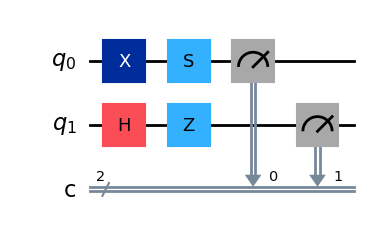

In [27]:
# Task 3c (Qiskit): Use the gate-error-aware calibration matrix M to mitigate the target circuit result
# Assumes prior cells created:
#   - noisy_sim (AerSimulator with the noise model)
#   - BASIS = ["00","01","10","11"]
#   - counts_to_prob_vector(counts, shots, basis=...)
#   - M (4x4 calibration matrix from Task 3b; i.e., M = 0.5*(M1+M2))

# ----------------------------
# 1) Define and execute the target circuit with few shots (more sampling noise)
# Target circuit from the task:
#   q0: X -> S
#   q1: H -> Z
# ----------------------------
qc_target = QuantumCircuit(2, 2)
qc_target.x(0)
qc_target.s(0)
qc_target.h(1)
qc_target.z(1)
qc_target.measure([0, 1], [0, 1])

shots_small = 256  # small -> noisier
res_noisy = noisy_sim.run(qc_target, shots=shots_small).result()
counts_noisy = res_noisy.get_counts()
V_circ = counts_to_prob_vector(counts_noisy, shots_small, basis=BASIS)
V_vec = np.array(V_circ, dtype=float)

# ----------------------------
# 2) Mitigate using the calibration matrix M: solve M X = V
# ----------------------------
try:
    X_mitig = np.linalg.solve(M, V_vec)
except np.linalg.LinAlgError:
    # Fallback: least-squares if M is singular/ill-conditioned
    X_mitig, *_ = np.linalg.lstsq(M, V_vec, rcond=None)

# Optional: simple physical post-processing (projection onto the simplex-ish)
# Clip negatives and renormalize.
X_mitig_proj = np.clip(X_mitig, 0.0, None)
s = X_mitig_proj.sum()
if s > 0:
    X_mitig_proj /= s

# ----------------------------
# 3) Compare raw vs mitigated (and optional ideal reference)
# ----------------------------
ideal_sim = AerSimulator()
res_ideal = ideal_sim.run(qc_target, shots=50_000).result()
counts_ideal = res_ideal.get_counts()
S_ref = counts_to_prob_vector(counts_ideal, 50_000, basis=BASIS)
S_vec = np.array(S_ref, dtype=float)

def rms_distance(Y, S):
    return math.sqrt(float(np.sum((np.array(Y) - np.array(S)) ** 2)))
print(f"Shots (noisy run): {shots_small}")
print("Counts (noisy):", counts_noisy)
print("\nBasis order:", BASIS)


qc_target.draw('mpl')



In [28]:
print("\nComparison (probabilities):")
# build pandas df for better formatting

data = []
for i, b in enumerate(BASIS):
    data.append({
        "bitstring": b,
        "raw V": V_vec[i],
        "mitigated X (solve)": X_mitig[i],
        "mitigated X (clipped+renorm)": X_mitig_proj[i],
        "ideal S": S_vec[i]
    })

df = pd.DataFrame(data)
df



Comparison (probabilities):


,bitstring,raw V,mitigated X (solve),mitigated X (clipped+renorm),ideal S
0,00,0.011719,-0.006236,0.000000,0.00000
1,01,0.480469,0.492010,0.488961,0.49634
2,10,0.031250,0.014612,0.014521,0.00000
3,11,0.476562,0.499613,0.496517,0.50366


In [ ]:
print("\nSanity checks:")
print("sum(raw V)            =", float(V_vec.sum()))
print("sum(mitigated X)      =", float(X_mitig.sum()))
print("sum(mitigated X proj) =", float(X_mitig_proj.sum()))
print("min(mitigated X)      =", float(X_mitig.min()))
print("min(mitigated X proj) =", float(X_mitig_proj.min()))

print("\nRMS distance to ideal reference S:")
print("Δ(raw V)            =", rms_distance(V_vec, S_vec))
print("Δ(mitigated X)      =", rms_distance(X_mitig, S_vec))
print("Δ(mitigated X proj) =", rms_distance(X_mitig_proj, S_vec))


## Solution Task 4

This technique exploits that many circuits produce an output distribution that is *concentrated* on a small subset of basis states. Instead of calibrating the full matrix \(M \in \mathbb{R}^{2^N \times 2^N}\), we restrict calibration and mitigation to a reduced subspace of size \(K \ll 2^N\).

---

### a) Identifying a relevant output subspace

#### 1) What is a *sparse output distribution*?

In quantum circuit measurements, the output is a probability distribution over computational basis states.  
A distribution is called **sparse** if most probabilities are (close to) zero, i.e., the probability mass is concentrated on only a few basis states.

Formally, for a distribution $p(b)$ over $2^N$ bitstrings $b$, sparsity means there exists a small set $\mathcal{S}$ such that

$$
\sum_{b \in \mathcal{S}} p(b) \approx 1,
\quad \text{with } |\mathcal{S}| = K \ll 2^N.
$$

This is common, for example, in circuits designed to prepare specific states (Bell states, GHZ states) or in algorithms where only certain outcomes are likely.

#### 2) Example of a 2-qubit circuit with support on fewer than 4 basis states

A standard example is the **Bell state circuit**:

- Apply \(H\) on qubit 0
- Apply \(CNOT\) on qubit 0 (control) and qubit 1 (target)

The ideal output state is:

$$
\lvert \Phi^+ \rangle = \frac{1}{\sqrt{2}}(\lvert 00\rangle + \lvert 11\rangle),
$$

so the ideal measurement distribution is supported only on two states:

$$
p(00)=\tfrac{1}{2},\quad p(11)=\tfrac{1}{2},\quad p(01)=0,\quad p(10)=0.
$$

Hence the relevant subspace can be chosen as: $$ S = \{00, 11\} $$ with \(K=2\).

#### 3) Practical criterion for selecting the reduced subspace

A practical way is to select the set of basis states whose measured (or simulated) probabilities exceed a threshold.

**Thresholding rule:**

Choose a threshold $ \tau > 0$ and define

$$
\mathcal{S} = \{ b \mid \hat{p}(b) \ge \tau \},
\quad K = |\mathcal{S}|.
$$

Typical choices:
- A fixed threshold (e.g., $\tau = 0.05 $)
- Or: choose the **top-$K$** outcomes such that their cumulative probability exceeds a target value, e.g.

$$
\sum_{b \in \mathcal{S}} \hat{p}(b) \ge 0.95.
$$

This is robust in practice because it adapts to the circuit and focuses calibration effort where the probability mass actually lies.

---

### b) Construction of a reduced calibration matrix

Let the selected subspace be $\mathcal{S} = \{b_1,\dots,b_K\}$ with $K \ll 2^N$.

#### 1) How calibration circuits are prepared only for states in the reduced subspace

For each basis state $b_j \in \mathcal{S}$, we run a **calibration circuit** that:
1. prepares $ \lvert b_j \rangle$ (using $X$ gates on qubits where the bit is 1),
2. measures in the computational basis,
3. records the observed distribution of measurement outcomes.

Crucially, we **do not** run calibration circuits for basis states outside $\mathcal{S}$.  
This reduces calibration cost from $2^N$ circuits to $K$ circuits.

#### 2) How $M_{\text{red}}$ is constructed from measurement data

In full readout-matrix mitigation, the calibration matrix $M$ is defined by columns:

- Column $j$ = measured outcome distribution when preparing state $j$

For the reduced matrix $M_{\text{red}}$ (where red stands for "reduced"), we do the same but only inside the selected subspace:

1. For each prepared state $b_j \in \mathcal{S}$, collect the measurement distribution.
2. Restrict the measured probabilities to outcomes in $\mathcal{S}$ (i.e., keep only probabilities for $b_1,\dots,b_K$).

Let $V_{\text{red}}^{(j)} \in \mathbb{R}^{K}$ denote the restricted measurement probabilities when preparing $b_j$.  
Then:

$$
M_{\text{red}} = \begin{pmatrix}
\mid & \mid &        & \mid \\
V_{\text{red}}^{(1)} & V_{\text{red}}^{(2)} & \cdots & V_{\text{red}}^{(K)} \\
\mid & \mid &        & \mid
\end{pmatrix}
\in \mathbb{R}^{K \times K}.
$$

In words: **$M_{\text{red}}$ is formed by placing the restricted calibration vectors as columns.**

#### 3) Comparison to the full matrix for $N=2$

For $N=2$:
- Full space size: $(2^2 = 4)$
- Full calibration:
  - **Number of calibration circuits:** $4$ (prepare 00,01,10,11)
  - **Matrix size:** $M \in \mathbb{R}^{4 \times 4}$

If the output is sparse and we select $K=2$ states (e.g., $\{00,11\}$):

- Reduced calibration:
  - **Number of calibration circuits:** $2$ (prepare only 00 and 11)
  - **Matrix size:** $M_{\text{red}} \in \mathbb{R}^{2 \times 2}$
This is a small gain for $N=2$, but for larger $N$ it is substantial because the full approach scales as $2^N$ while the reduced approach scales as $K$.